# Исследовательский анализ данных

## Цель

Исследовать структуру эксперимента Criteo Uplift Modeling Dataset и подготовить данные к оценке инкрементального эффекта рекламы.

На этапе EDA необходимо:

1. проверить распределение пользователей между экспериментальной и контрольной группами;
2. исследовать связь между назначением пользователя в экспериментальную группу и фактическим рекламным воздействием (`exposure`);
3. оценить частоту визитов и конверсий;
4. проверить баланс пользовательских признаков между экспериментальной и контрольной группами;
5. сравнить целевые метрики между группами до формальной оценки причинного эффекта.

**Treatment** — экспериментальная группа: пользователю разрешено рекламное воздействие.

**Control** — контрольная группа: рекламное воздействие блокируется.

**Exposure** — факт реального рекламного воздействия на пользователя.

**Outcome** — измеряемый результат эксперимента. В данном датасете такими результатами являются `visit` и `conversion`.

In [1]:
from pathlib import Path
import json
import re

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path.cwd().parent
REPORTS_DIR = PROJECT_ROOT / "reports"

AUDIT_PATH = REPORTS_DIR / "data_audit_summary.json"

print(PROJECT_ROOT)
print(AUDIT_PATH)

C:\Users\Julia\PycharmProjects\marketing-incrementality-criteo
C:\Users\Julia\PycharmProjects\marketing-incrementality-criteo\reports\data_audit_summary.json


In [3]:
with AUDIT_PATH.open("r", encoding="utf-8") as file:
    audit = json.load(file)

audit.keys()

dict_keys(['file', 'file_size_gb', 'rows', 'columns', 'missing_values', 'binary_value_counts', 'treatment_exposure', 'rates'])

## 1. Дизайн эксперимента

Сначала необходимо понять, как пользователи распределены между экспериментальной и контрольной группами и как назначение в экспериментальную группу связано с фактическим показом рекламы.

Для оценки причинного эффекта важно различать:

- `treatment` — назначение пользователя в экспериментальную группу;
- `exposure` — фактический контакт пользователя с рекламой.

Назначение в экспериментальную группу не означает, что пользователь обязательно увидел рекламу: фактическое рекламное воздействие могло не произойти.

In [4]:
# Смотрим размер групп
treatment_counts = audit["binary_value_counts"]["treatment"]
treatment_df = pd.DataFrame({
    "group": ["Control", "Treatment"],
    "users": [
        treatment_counts["0"],
        treatment_counts["1"],
    ]
})

treatment_df["share"] = (
    treatment_df["users"] / treatment_df["users"].sum()
)
treatment_df

,group,users,share
0,Control,2096937,0.15
1,Treatment,11882655,0.85


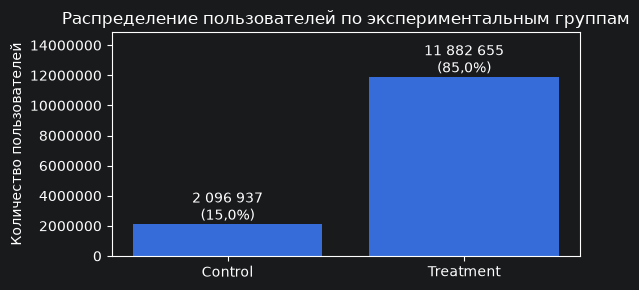

In [32]:
fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.bar(
    treatment_df["group"],
    treatment_df["users"]
)

ax.set_title("Распределение пользователей по экспериментальным группам")
ax.set_ylabel("Количество пользователей")

ax.ticklabel_format(
    style="plain",
    axis="y"
)

for bar, users, share in zip(
    bars,
    treatment_df["users"],
    treatment_df["share"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{users:,.0f}".replace(",", " ")
        + f"\n({share:.1%})".replace(".", ","),
        ha="center",
        va="bottom"
    )

ax.set_ylim(
    0,
    treatment_df["users"].max() * 1.25
)

plt.tight_layout()
plt.show()

### Вывод

85% пользователей относятся к экспериментальной группе, 15% — к контрольной.

Разный размер групп сам по себе не мешает оценивать эффект эксперимента, если распределение пользователей между ними было случайным. Однако различие в размерах групп необходимо учитывать при дальнейшем сравнении метрик и оценке статистической неопределенности.

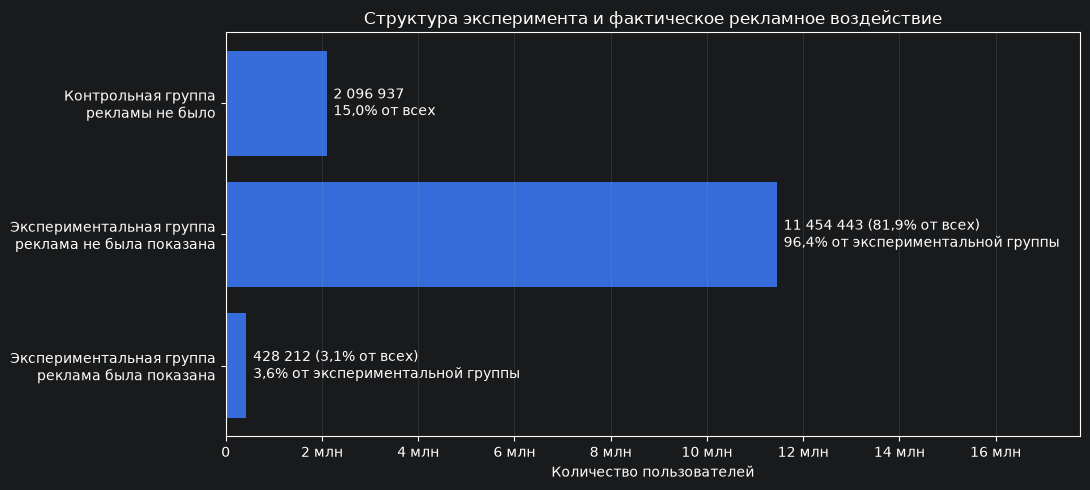

In [33]:
from matplotlib.ticker import FuncFormatter

plot_df = treatment_exposure_df.copy()


def make_group_label(row):
    if row["treatment"] == 0 and row["exposure"] == 0:
        return "Контрольная группа\nрекламы не было"

    if row["treatment"] == 1 and row["exposure"] == 0:
        return "Экспериментальная группа\nреклама не была показана"

    if row["treatment"] == 1 and row["exposure"] == 1:
        return "Экспериментальная группа\nреклама была показана"

    return "Другая комбинация"


plot_df["group_label"] = plot_df.apply(
    make_group_label,
    axis=1
)

# Логичный порядок групп
plot_df["order"] = plot_df.apply(
    lambda row:
        0 if row["treatment"] == 0
        else 1 if row["exposure"] == 0
        else 2,
    axis=1
)

plot_df = (
    plot_df
    .sort_values("order")
    .reset_index(drop=True)
)

total_users = plot_df["users"].sum()

treatment_users = plot_df.loc[
    plot_df["treatment"] == 1,
    "users"
].sum()

plot_df["share_total"] = (
    plot_df["users"] / total_users
)

plot_df["share_treatment"] = None

mask_treatment = plot_df["treatment"] == 1

plot_df.loc[
    mask_treatment,
    "share_treatment"
] = (
    plot_df.loc[mask_treatment, "users"]
    / treatment_users
)


fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.barh(
    plot_df["group_label"],
    plot_df["users"]
)

ax.set_title(
    "Структура эксперимента и фактическое рекламное воздействие"
)

ax.set_xlabel("Количество пользователей")

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos:
            f"{x / 1_000_000:.0f} млн"
            if x >= 1_000_000
            else f"{x:,.0f}".replace(",", " ")
    )
)


for bar, row in zip(
    bars,
    plot_df.itertuples()
):
    users_text = f"{row.users:,.0f}".replace(",", " ")
    total_share = f"{row.share_total:.1%}".replace(".", ",")

    if row.treatment == 1:
        treatment_share = (
            f"{row.share_treatment:.1%}"
            .replace(".", ",")
        )

        label = (
            f"{users_text} ({total_share} от всех)\n"
            f"{treatment_share} от экспериментальной группы"
        )

    else:
        label = (
            f"{users_text}\n"
            f"{total_share} от всех"
        )

    ax.text(
        bar.get_width() + total_users * 0.01,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left"
    )


# Расширяем область справа под подписи
ax.set_xlim(
    0,
    plot_df["users"].max() * 1.55
)

ax.invert_yaxis()

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

### Вывод

В экспериментальную группу вошли около 11,88 млн пользователей, однако фактически рекламное воздействие получили только 428 тыс. человек — около 3,6% экспериментальной группы.

В контрольной группе случаев фактического рекламного воздействия не обнаружено.

Таким образом, важно различать два понятия:

- **treatment assignment** — назначение пользователя в экспериментальную группу;
- **actual exposure** — фактический контакт пользователя с рекламой.

Для первичной оценки причинного эффекта корректнее сравнивать экспериментальную и контрольную группы, поскольку именно принадлежность к группе определяется условиями эксперимента, тогда как факт реального показа рекламы может зависеть и от других факторов.

## 2. Целевые события

В датасете используются два результата эксперимента (**outcomes**):

- `visit` — совершил ли пользователь визит;
- `conversion` — совершил ли пользователь целевую конверсию.

Сначала оценим частоту этих событий по всей выборке, затем сравним показатели между контрольной и экспериментальной группами.

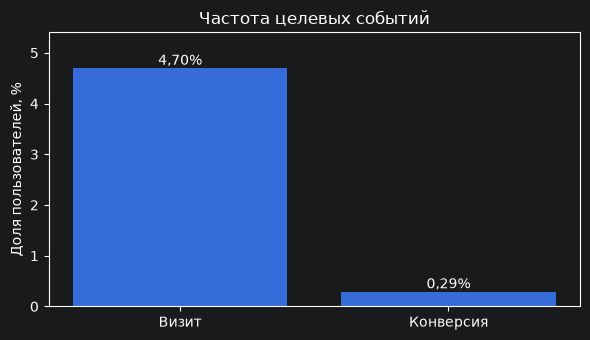

In [36]:
# Частота событий во всем датасете
fig, ax = plt.subplots(figsize=(6, 3.5))

bars = ax.bar(
    outcome_rates["event"],
    outcome_rates["percent"]
)

ax.set_title("Частота целевых событий")
ax.set_ylabel("Доля пользователей, %")

for bar, value in zip(
    bars,
    outcome_rates["percent"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%".replace(".", ","),
        ha="center",
        va="bottom"
    )

ax.set_ylim(
    0,
    outcome_rates["percent"].max() * 1.15
)

plt.tight_layout()
plt.show()

### Вывод

Визит совершили около 4,7% пользователей, а конверсию — только около 0,29%.

Конверсия является редким событием: подавляющее большинство пользователей не совершает целевого действия. Поэтому в данных наблюдается **дисбаланс классов (class imbalance)** — пользователей без конверсии значительно больше, чем пользователей с конверсией.

Это необходимо учитывать при дальнейшем моделировании и оценке качества uplift-модели.

## 3. Сравнение целевых метрик между группами

Теперь сравним частоту визитов и конверсий между контрольной и экспериментальной группами.

На данном этапе рассматриваем различия описательно: сравниваем наблюдаемые значения метрик, но пока не делаем вывод о статистической значимости эффекта.

Формальную оценку причинного эффекта, доверительные интервалы и статистические тесты проведем отдельно после завершения EDA.

In [35]:
GROUP_METRICS_PATH = REPORTS_DIR / "group_metrics.csv"

group_metrics = pd.read_csv(GROUP_METRICS_PATH)

metrics_table = group_metrics[
    [
        "group",
        "users",
        "visits",
        "visit_rate",
        "conversions",
        "conversion_rate"
    ]
].copy()

metrics_table["visit_rate"] *= 100
metrics_table["conversion_rate"] *= 100

metrics_table = metrics_table.rename(
    columns={
        "group": "Группа",
        "users": "Пользователи",
        "visits": "Визиты",
        "visit_rate": "Доля визитов, %",
        "conversions": "Конверсии",
        "conversion_rate": "Доля конверсий, %",
    }
)

metrics_table.style.format(
    {
        "Пользователи": "{:,.0f}",
        "Визиты": "{:,.0f}",
        "Доля визитов, %": "{:.2f}",
        "Конверсии": "{:,.0f}",
        "Доля конверсий, %": "{:.2f}",
    }
).set_properties(
    **{
        "text-align": "center",
        "min-width": "130px"
    }
).set_table_styles(
    [
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("min-width", "150px"),
                ("white-space", "normal"),
            ],
        }
    ]
)

,Группа,Пользователи,Визиты,"Доля визитов, %",Конверсии,"Доля конверсий, %"
0,Контрольная группа,"2,096,937","80,105",3.82,"4,063",0.19
1,Экспериментальная группа,"11,882,655","576,824",4.85,"36,711",0.31


### Вывод

В экспериментальной группе доля пользователей, совершивших визит, выше, чем в контрольной: 4,85% против 3,82%.

Разница составляет около **1,03 процентного пункта**, или примерно **27% относительно контрольной группы**.

Аналогичная картина наблюдается для конверсий: в экспериментальной группе конверсию совершили 0,31% пользователей, в контрольной — 0,19%.

Разница составляет около **0,12 процентного пункта**, или примерно **59% относительно контрольной группы**.

На уровне описательной статистики экспериментальная группа показывает более высокие значения обеих целевых метрик. Однако этого пока недостаточно, чтобы утверждать, что различия вызваны рекламным воздействием: необходимо оценить статистическую неопределенность и проверить значимость наблюдаемого эффекта.

## 4. Баланс пользовательских признаков

Перед оценкой эффекта рекламы проверим, насколько похожи контрольная и экспериментальная группы по исходным признакам `f0–f11`.

### Почему не используем t-test

Для проверки баланса признаков между группами не используем t-test, потому что выборка очень большая — почти 14 млн наблюдений. На такой выборке даже очень маленькая разница в средних может оказаться статистически значимой, хотя на практике она почти ничего не значит. Поэтому здесь важнее оценить не сам факт различия, а **его размер**. Для этого используем **SMD (Standardized Mean Difference)** — стандартизированную разницу средних.

Чем ближе SMD к нулю, тем больше группы похожи друг на друга по соответствующему признаку.

В качестве ориентира считаем:

- `|SMD| < 0,05` — очень хороший баланс;
- `|SMD| < 0,10` — приемлемый баланс;
- `|SMD| ≥ 0,10` — возможное заметное различие между группами.

In [40]:
BALANCE_PATH = REPORTS_DIR / "covariate_balance.csv"

balance = pd.read_csv(BALANCE_PATH)

balance_table = balance[
    [
        "feature",
        "control_mean",
        "experiment_mean",
        "smd",
        "balance_status"
    ]
].copy()

balance_table = balance_table.rename(
    columns={
        "feature": "Признак",
        "control_mean": "Среднее: контрольная группа",
        "experiment_mean": "Среднее: экспериментальная группа",
        "smd": "SMD",
        "balance_status": "Оценка баланса",
    }
)

balance_table.style.format(
    {
        "Среднее: контрольная группа": "{:.3f}",
        "Среднее: экспериментальная группа": "{:.3f}",
        "SMD": "{:.3f}",
    }
).set_properties(
    **{
        "text-align": "center",
        "min-width": "130px",
    }
)

,Признак,Среднее: контрольная группа,Среднее: экспериментальная группа,SMD,Оценка баланса
0,f0,19.652,19.615,-0.007,Баланс приемлемый
1,f1,10.068,10.070,0.024,Баланс приемлемый
2,f2,8.448,8.446,-0.006,Баланс приемлемый
3,f3,4.233,4.169,-0.049,Баланс приемлемый
4,f4,10.337,10.339,0.008,Баланс приемлемый
5,f5,4.039,4.027,-0.031,Баланс приемлемый
6,f6,-4.000,-4.183,-0.040,Баланс приемлемый
7,f7,5.080,5.106,0.021,Баланс приемлемый
8,f8,3.935,3.933,-0.022,Баланс приемлемый
9,f9,15.886,16.053,0.024,Баланс приемлемый


### Вывод

Для всех 12 признаков абсолютное значение SMD ниже 0,05, а значит существенно ниже распространенного практического порога 0,10.

Наибольшее различие наблюдается по признаку f3: |SMD| = 0,0488. Даже оно остается небольшим относительно вариативности самого признака.

Таким образом, по доступным исходным признакам контрольная и экспериментальная группы хорошо сбалансированы. Заметного различия состава групп до рекламного воздействия не обнаружено.